# Example: Quantile Regression & Asymmetric Loss

Demonstrates asymmetric pinball loss minimization for financial risk corridors and conditional percentiles.

10th Percentile Slope: 1.0093 (downside floor)
50th Percentile Slope: 1.5545 (median LAD fit)
90th Percentile Slope: 2.1408 (upside ceiling)


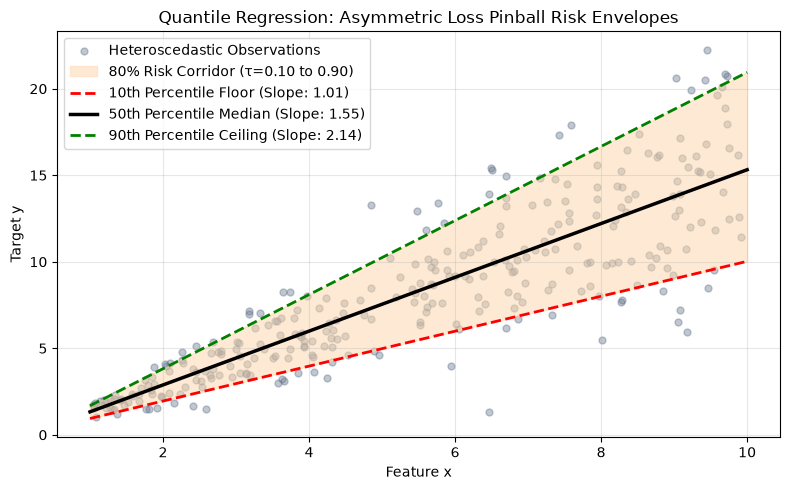

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.quantile import QuantileRegressorScratch

np.random.seed(42)
x = np.random.uniform(1, 10, 300)
# Heteroscedastic noise
y = 1.5 * x + np.random.normal(0, 0.4 * x, 300)
X = x.reshape(-1, 1)

q10 = QuantileRegressorScratch(quantile=0.10).fit(X, y)
q50 = QuantileRegressorScratch(quantile=0.50).fit(X, y)
q90 = QuantileRegressorScratch(quantile=0.90).fit(X, y)

print(f"10th Percentile Slope: {q10.weights[0]:.4f} (downside floor)")
print(f"50th Percentile Slope: {q50.weights[0]:.4f} (median LAD fit)")
print(f"90th Percentile Slope: {q90.weights[0]:.4f} (upside ceiling)")

# Visualize Quantile Regression Pinball Envelope
grid_x = np.linspace(1, 10, 100).reshape(-1, 1)
pred_10 = q10.predict(grid_x)
pred_50 = q50.predict(grid_x)
pred_90 = q90.predict(grid_x)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, color='#64748b', s=25, label='Heteroscedastic Observations')
plt.fill_between(grid_x[:, 0], pred_10, pred_90, color='#fed7aa', alpha=0.5, label='80% Risk Corridor (τ=0.10 to 0.90)')
plt.plot(grid_x[:, 0], pred_10, 'r--', lw=2, label=f'10th Percentile Floor (Slope: {q10.weights[0]:.2f})')
plt.plot(grid_x[:, 0], pred_50, 'k-', lw=2.5, label=f'50th Percentile Median (Slope: {q50.weights[0]:.2f})')
plt.plot(grid_x[:, 0], pred_90, 'g--', lw=2, label=f'90th Percentile Ceiling (Slope: {q90.weights[0]:.2f})')

plt.title("Quantile Regression: Asymmetric Loss Pinball Risk Envelopes")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Modeling conditional percentiles to capture expanding variance without parametric assumptions.
- Constructing risk corridors for asymmetric downside/upside forecasting.